Load the data

In [1]:
from preprocessing import load_folder_paths, get_volume
from scipy import ndimage
import matplotlib.pyplot as plt
import os
import SimpleITK as sitk
import numpy as np

paths = load_folder_paths()
dataset_path = os.path.expanduser('~/Desktop/UniToBrain')
path = os.path.join(dataset_path, 'MOL-063')
# v = get_volume(path, extract_brain=False, filter=True, window_params=(80, 160), correct_motion=False, standardize=False, spatial_downsampling_factor=2, temporal_downsampling_factor=1)

Interactive Visualization Functions

In [2]:
from ipywidgets import interact, IntSlider
from IPython.display import clear_output
from math import ceil

def overlay_volume_sequence_interactive(volume_seq):
    num_overlays = len(volume_seq) - 1
    nrows = ceil(num_overlays ** 0.5)
    ncols = ceil(num_overlays / nrows)
    print(f"{nrows=} {ncols=}")
    def plot_slice(slice_idx):

        fig, axes = plt.subplots(nrows, 
                                ncols, 
                                figsize=(5*ncols, 5*nrows),
                                squeeze=True)
        if nrows == 1:
            if ncols == 1:
                axes = [[axes]]
            else:
                axes = [axes]
        print(f"{axes=}")
        for i in range(num_overlays):
            ax = axes[i // ncols][i % ncols]
            print(f"{ax=}")
            ax.imshow(volume_seq[0][slice_idx], cmap="gray")
            ax.imshow(volume_seq[i+1][slice_idx], cmap="hot", alpha=0.5)
        plt.show(block=True)
    
    interact(
        plot_slice,
        slice_idx=IntSlider(
            min=0,
            max=len(volume_seq[0])-1, 
            step=1,
            value=0,
            description='Slice:'
        )
    )

def multi_vol_seq_interactive(volume_seqs, titles=None, consistent_intensity_scaling=False):
    """
    Interactive plot of multiple volume sequences using ipywidgets
    
    Parameters:
    - volume_seqs: List of 4D volume sequences to display
    - titles: Optional list of titles for each sequence
    """
    clear_output(wait=True)
    if titles is None:
        titles = [f"Volume {i+1}" for i in range(len(volume_seqs))]
        
    num_volumes = len(volume_seqs)
    nrows = int(num_volumes ** 0.5)
    ncols = (num_volumes + nrows - 1) // nrows
    
    min_max_values = []
    if not consistent_intensity_scaling:
        for volume_seq in volume_seqs:
            min_max_values.append((np.min(volume_seq), np.max(volume_seq)))
    else:
        min_max_values = [(np.min(volume_seqs), np.max(volume_seqs)) for _ in range(len(volume_seqs))]

    def plot_volumes(time_idx, slice_idx):
        fig, axes = plt.subplots(nrows, ncols, 
                                figsize=(5*ncols, 5*nrows),
                                squeeze=True)
        if nrows == 1:
            if ncols == 1:
                axes = [[axes]]
            else:
                axes = [axes]
                
        for i, (volume_seq, title) in enumerate(zip(volume_seqs, titles)):
            row, col = i // ncols, i % ncols
            ax = axes[row][col]
            
            t = min(time_idx, len(volume_seq) - 1)
            s = min(slice_idx, len(volume_seq[t]) - 1)

            vmin, vmax = min_max_values[i]

            im = ax.imshow(volume_seq[t][s], cmap='magma', vmin=vmin, vmax=vmax)
            ax.set_title(title)
            plt.colorbar(im, ax=ax)
            
        plt.tight_layout()
        # plt.show()
        
    max_time = max(len(vol) for vol in volume_seqs) - 1
    max_slice = max(len(vol[0]) for vol in volume_seqs) - 1
    
    interact(
        plot_volumes,
        time_idx=IntSlider(min=0, max=max_time, step=1, value=0, description='Time:'),
        slice_idx=IntSlider(min=0, max=max_slice, step=1, value=0, description='Slice:')
    )


In [3]:
from IPython.display import clear_output
# Callback invoked when the StartEvent happens, sets up our new data.
def start_plot():
    global metric_values, multires_iterations

    metric_values = []
    multires_iterations = []


# Callback invoked when the EndEvent happens, do cleanup of data and figure.
def end_plot():
    global metric_values, multires_iterations

    del metric_values
    del multires_iterations
    # Close figure, we don't want to get a duplicate of the plot latter on.
    plt.close()


# Callback invoked when the IterationEvent happens, update our data and display new figure.
def plot_values(registration_method, metric_name='Metric Value'):
    if registration_method.GetOptimizerIteration() % 10 == 0:
        global metric_values, multires_iterations

        metric_values.append(registration_method.GetMetricValue())
        # Clear the output area (wait=True, to reduce flickering), and plot current data
        clear_output(wait=True)
        # Plot the similarity metric values
        plt.plot(metric_values, "r")
        plt.plot(
            multires_iterations,
            [metric_values[index] for index in multires_iterations],
            "b*",
        )
        plt.xlabel("Iteration Number", fontsize=12)
        plt.ylabel(metric_name, fontsize=12)
        plt.show()


# Callback invoked when the sitkMultiResolutionIterationEvent happens, update the index into the
# metric_values list.
def update_multires_iterations():
    global metric_values, multires_iterations
    multires_iterations.append(len(metric_values))

In [4]:
from IPython.display import clear_output
# Callback invoked when the StartEvent happens, sets up our new data.
def start_plot():
    global metric_values, multires_iterations

    metric_values = []
    multires_iterations = []


# Callback invoked when the EndEvent happens, do cleanup of data and figure.
def end_plot():
    global metric_values, multires_iterations

    del metric_values
    del multires_iterations
    # Close figure, we don't want to get a duplicate of the plot latter on.
    plt.close()


# Callback invoked when the IterationEvent happens, update our data and display new figure.
def plot_values(registration_method, metric_name='Metric Value'):
    if registration_method.GetOptimizerIteration() % 10 == 0:
        global metric_values, multires_iterations

        metric_values.append(registration_method.GetMetricValue())
        # Clear the output area (wait=True, to reduce flickering), and plot current data
        clear_output(wait=True)
        # Plot the similarity metric values
        plt.plot(metric_values, "r")
        plt.plot(
            multires_iterations,
            [metric_values[index] for index in multires_iterations],
            "b*",
        )
        plt.xlabel("Iteration Number", fontsize=12)
        plt.ylabel(metric_name, fontsize=12)
        plt.show()


# Callback invoked when the sitkMultiResolutionIterationEvent happens, update the index into the
# metric_values list.
def update_multires_iterations():
    global metric_values, multires_iterations
    multires_iterations.append(len(metric_values))

In [5]:
from IPython.display import clear_output
# Callback invoked when the StartEvent happens, sets up our new data.
def start_plot_2():
    global metric_values, multires_iterations

    metric_values = []
    multires_iterations = []


# Callback invoked when the EndEvent happens, do cleanup of data and figure.
def end_plot_2():
    global metric_values, multires_iterations

    del metric_values
    del multires_iterations
    # Close figure, we don't want to get a duplicate of the plot latter on.
    plt.close()


# Callback invoked when the IterationEvent happens, update our data and display new figure.
def plot_values_2(reference, moving,registration_method, metric_name='Metric Value'):
    if registration_method.GetOptimizerIteration() % 10 == 0:
        global metric_values, multires_iterations
        fig
        metric_values.append(registration_method.GetMetricValue())
        # Clear the output area (wait=True, to reduce flickering), and plot current data
        clear_output(wait=True)
        # Plot the similarity metric values
        plt.plot(metric_values, "r")
        plt.plot(
            multires_iterations,
            [metric_values[index] for index in multires_iterations],
            "b*",
        )
        plt.xlabel("Iteration Number", fontsize=12)
        plt.ylabel(metric_name, fontsize=12)
        plt.show()


# Callback invoked when the sitkMultiResolutionIterationEvent happens, update the index into the
# metric_values list.
def update_multires_iterations():
    global metric_values, multires_iterations
    multires_iterations.append(len(metric_values))

In [6]:
def plot_volume_slices(volume, title=None, cmap='magma'):
    """
    Plots all slices of a 3D volume in a rectangular grid arrangement.
    
    Parameters:
    - volume: 3D numpy array of shape (D, H, W)
    - title: Optional string for overall figure title
    - cmap: Colormap to use for plotting
    """
    D = volume.shape[0]
    vmin, vmax = np.min(volume), np.max(volume)

    # Calculate grid dimensions to arrange plots in a roughly square layout
    n_rows = int(np.ceil(np.sqrt(D)))
    n_cols = int(np.ceil(D / n_rows))
    
    # Create figure and subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
    if title:
        fig.suptitle(title, fontsize=16)
    
    # Flatten axes array for easier iteration
    axes = axes.flatten()
    
    # Plot each slice
    for i in range(D):
        axes[i].imshow(volume[i], cmap=cmap, vmin=vmin, vmax=vmax)
        axes[i].axis('off')
        axes[i].set_title(f'Slice {i}')
    
    # Turn off any empty subplots
    for i in range(D, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

## Drawbacks of 3D registration
Rotation along the y-axis (the height) of each volume causes interpolation between the slices.

In [7]:
v_unwindowed = get_volume(path, extract_brain=False, filter=True, window_params=None, correct_motion=False, standardize=False, spatial_downsampling_factor=2, temporal_downsampling_factor=1)

Loading /Users/simonma/Desktop/UniToBrain/MOL-063...
Processing /Users/simonma/Desktop/UniToBrain/MOL-063...
Done!


In [8]:
# multi_vol_seq_interactive([v_unwindowed, np.clip(v_unwindowed, 0, 160)])

In [9]:
from skimage import morphology
from scipy import ndimage
from numba import jit

@jit(nopython=True)
def get_threshold_mask(slice, min_val=-40, max_val=150):
    return (min_val < slice) & (slice < max_val)

@jit(nopython=True)
def apply_mask(a: np.ndarray, mask: np.ndarray):
    min_val = np.min(a)
    return (a - min_val) * mask + min_val

def mask_slice(slice, threshold_min=-40, threshold_max=400, structuring_element_dims=(3, 3)):
    smoothened = ndimage.gaussian_filter(slice, sigma=2.0)
    # ---Simpler Version---
    mask = get_threshold_mask(smoothened, min_val=threshold_min, max_val=3000)
    mask = ndimage.binary_erosion(mask, np.ones(structuring_element_dims), iterations=2)
    # Remove small objects
    mask = morphology.remove_small_objects(mask, 800)
    # mask=ndimage.binary_dilation(mask, np.ones(structuring_element_dims), iterations=1)
    mask = ndimage.binary_fill_holes(mask)
    return apply_mask(slice, mask)

    # mask = get_threshold_mask(smoothened, min_val=threshold_min, max_val=threshold_max)
    # mask = ndimage.binary_erosion(mask, np.ones(structuring_element_dims), iterations=2)
    # # Remove small objects
    # mask = morphology.remove_small_objects(mask, 800)
    # # Fill small holes
    # mask = ndimage.binary_dilation(mask, np.ones(structuring_element_dims), iterations=2)
    # mask = ndimage.binary_fill_holes(mask)
    # return apply_mask(slice, mask)

def preprocess_slice_for_registration(slice, threshold_min=-40, threshold_max=150, structuring_element_dims=(3, 3), reg_window_min=20, reg_window_max=60):
    masked = mask_slice(slice, threshold_min=threshold_min, threshold_max=threshold_max, structuring_element_dims=structuring_element_dims)
    return np.clip(masked, reg_window_min, reg_window_max)

def mask_volume_seq(volume_seq: np.ndarray, threshold_min=-40, threshold_max=150, structuring_element_dims=(3, 3)):
    masked_volume_seq = np.zeros_like(volume_seq)
    for t, volume in enumerate(volume_seq):
        for i, slice in enumerate(volume):        
            masked_volume_seq[t, i] = mask_slice(slice, threshold_min=threshold_min, threshold_max=threshold_max, structuring_element_dims=structuring_element_dims)
    return masked_volume_seq

def preprocess_volume_seq(volume_seq: np.ndarray, threshold_min=-40, threshold_max=150, structuring_element_dims=(3, 3), reg_window_min=20, reg_window_max=60):
    masked_volume_seq = mask_volume_seq(volume_seq, threshold_min=threshold_min, threshold_max=threshold_max, structuring_element_dims=structuring_element_dims)
    return np.clip(masked_volume_seq, reg_window_min, reg_window_max)

v_preprocessed = preprocess_volume_seq(v_unwindowed, reg_window_min=0, reg_window_max=200, threshold_max=150)

In [10]:
multi_vol_seq_interactive([np.clip(v_unwindowed, 0, 160), v_preprocessed], consistent_intensity_scaling=True)

interactive(children=(IntSlider(value=0, description='Time:', max=17), IntSlider(value=0, description='Slice:'…

In [19]:
from time import sleep
def register_volume_inplane_weighted(moving_volume: np.ndarray, reference_volume: np.ndarray, n_samples: int = 5, 
               lr: float = 1.0, n_iters: int = 200, relaxation_factor: float = 0.99, 
               gradient_magnitude_tolerance: float = 1e-5, max_step: float = 4.0, min_step: float = 5e-3, 
               spacing: tuple = (1, 1), multi_res: bool = False, smoothing_sigma: float = 1.0, interpolator=sitk.sitkLinear,
               mask=True, reg_window_min=-100, reg_window_max=300, threshold_min=0, threshold_max=500,
               center_index=None, shrink_factors=[2, 1], smoothing_sigmas=[2, 0], wait=False,
               verbose: bool = False):
    
    Y, Z, X = moving_volume.shape
    
    if n_samples > Y: n_samples = Y
    elif n_samples < 1: n_samples = 1
    middle = center_index if center_index is not None else Y // 2 + 2
    half_range = n_samples // 2
    slice_indices = np.linspace(middle - half_range, middle + half_range, n_samples, dtype=int)
    

    transforms = []
    weights = np.zeros(n_samples)

    def command_iteration(method):
        if (method.GetOptimizerIteration()) % 25 == 0:
            print(f"Iteration: {method.GetOptimizerIteration()}")
            print(f"Metric value: {method.GetMetricValue():.4f}")

    # Setup interactive plotting
    def plot_overlay(fixed_img, moving_img, iteration):
        clear_output(wait=True)
        
        plt.clf()  # Clear current figure
        plt.imshow(fixed_img, cmap='Greys_r')
        plt.imshow(moving_img, cmap='hot', alpha=0.5, vmin=0, vmax=80)
        plt.title(f'Registration Progress - Iteration {iteration}')
        plt.axis('off')
        plt.tight_layout()
        plt.show(block=True)

    # Register each sampled slice
    for pos, slice_idx in enumerate(slice_indices):
        if verbose:
            print(f"Registering slice {slice_idx} of {Y}")
        
        # Standard preprocessing for registration
        if mask:
            moving_slice = preprocess_slice_for_registration(moving_volume[slice_idx], reg_window_min=reg_window_min, reg_window_max=reg_window_max, threshold_min=threshold_min, threshold_max=threshold_max)
            fixed_slice = preprocess_slice_for_registration(reference_volume[slice_idx], reg_window_min=reg_window_min, reg_window_max=reg_window_max, threshold_min=threshold_min, threshold_max=threshold_max)
        else:
            moving_slice = np.clip(moving_volume[slice_idx], 0, 160)
            fixed_slice = np.clip(reference_volume[slice_idx], 0, 160)
            

        # Set min pixel value to 0 so that background aligns with pixels moved in by transformation during registration
        min_pixel_value = np.min(moving_slice)
        moving_slice, fixed_slice = moving_slice - min_pixel_value, fixed_slice - min_pixel_value
        
        if verbose:
            print(f"{min_pixel_value=}")
        # Convert to SimpleITK images
        moving = sitk.GetImageFromArray(moving_slice)
        fixed = sitk.GetImageFromArray(fixed_slice)
        
        if smoothing_sigma:
            moving = sitk.DiscreteGaussian(moving, smoothing_sigma)
            fixed = sitk.DiscreteGaussian(fixed, smoothing_sigma)
        
        # Set 2D spacing
        moving.SetSpacing(spacing)
        fixed.SetSpacing(spacing)
        
        # Initialize 2D transform
        initial_transform = sitk.CenteredTransformInitializer(
            fixed,
            moving,
            sitk.Euler2DTransform(),
            sitk.CenteredTransformInitializerFilter.GEOMETRY
        )
        
        # Setup registration method
        registration_method = sitk.ImageRegistrationMethod()
        registration_method.SetMetricAsMeanSquares()
        
        # Optimizer settings
        registration_method.SetOptimizerAsRegularStepGradientDescent(
            learningRate=lr,
            maximumStepSizeInPhysicalUnits=max_step,
            minStep=min_step,
            numberOfIterations=n_iters,
            gradientMagnitudeTolerance=gradient_magnitude_tolerance,
            relaxationFactor=relaxation_factor,
            
        )

        current_moving = sitk.GetArrayFromImage(moving)
        plot_overlay(fixed_slice, current_moving, 0)

        if multi_res:
            registration_method.SetShrinkFactorsPerLevel(shrinkFactors=shrink_factors)
            registration_method.SetSmoothingSigmasPerLevel(smoothingSigmas=smoothing_sigmas)
            registration_method.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()
        registration_method.SetInitialTransform(initial_transform)
        registration_method.SetInterpolator(interpolator)
        
                # Add observer to visualize registration progress
        def command_iteration(method):
            if (method.GetOptimizerIteration()) % 25 == 0:
                # Get current transform and apply to moving image
                transform = method.GetInitialTransform()
                transformed = sitk.Resample(
                    moving, fixed,
                    transform,
                    sitk.sitkLinear,
                    0.0,
                    moving.GetPixelID()
                )
                if wait:
                    sleep(0.5)
                # Convert to numpy and plot
                current_moving = sitk.GetArrayFromImage(transformed)
                plot_overlay(fixed_slice, current_moving, method.GetOptimizerIteration())
                print(f"Iteration: {method.GetOptimizerIteration()}")
                print(f"Metric value: {method.GetMetricValue():.4f}")
        if verbose:
            # registration_method.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(registration_method))
            registration_method.AddCommand(sitk.sitkStartEvent, start_plot)
            registration_method.AddCommand(sitk.sitkEndEvent, end_plot)
            registration_method.AddCommand(sitk.sitkMultiResolutionIterationEvent, update_multires_iterations)
            registration_method.AddCommand(sitk.sitkIterationEvent, lambda: plot_values(registration_method, 'MSE'))

        try:
            final_transform = registration_method.Execute(fixed, moving)
            # resampled = sitk.Resample(moving, fixed, final_transform, interpolator, 0.0, moving.GetPixelID())
            # moving_slice = sitk.GetArrayFromImage(resampled)
            # print(slice_idx)
            # return moving_slice + min_pixel_value
            

            # position_weight = 1 / ((slice_idx - middle) / (half_range / 2)) # The further away from the center, the lower the weight
            metric_value = registration_method.GetMetricValue()
            # weight = 1 / ((metric_value) + 1e-10 ** 0.5) * position_weight
            weight = 1 / (metric_value + 1e-10)
            weights[pos] = weight


            if verbose:
                print(f"Stopping condition: {registration_method.GetOptimizerStopConditionDescription()}")
                print(f"Metric value: {metric_value:.4f}")
            # Store transform parameters and weight
            params = final_transform.GetParameters()
            center = final_transform.GetCenter()
            transforms.append((params, center))

            # Check for extreme transformations
            angle_deg = np.degrees(params[0])  # Convert angle from radians to degrees
            tx, ty = params[1], params[2]
            
            if abs(angle_deg) > 15 or abs(tx) > 10 or abs(ty) > 10:
                print(f"Info: Large transformation detected for slice {slice_idx}:")
                print(f"    Angle: {angle_deg:.2f}°, Translation: ({tx:.2f}, {ty:.2f})")
            
        except RuntimeError as e:
            print(f"Registration failed for slice {slice_idx}: {e}")
            continue
        
    # Normalize weights
    weights = weights / np.sum(weights)
    
    # Compute weighted average transformation
    avg_angle = 0
    avg_tx = 0
    avg_ty = 0
    avg_cx = 0
    avg_cy = 0
    

    for (params, center), weight in zip(transforms, weights):
        angle, tx, ty = params[0], params[1], params[2]
        avg_angle += angle * weight
        avg_tx += tx * weight
        avg_ty += ty * weight
        avg_cx += center[0] * weight
        avg_cy += center[1] * weight
    
    if verbose:
        print(f"{avg_angle=:.4f} {avg_tx=:.4f} {avg_ty=:.4f} {avg_cx=:.4f} {avg_cy=:.4f}")
    # print(f"Time taken: {time() - t1}")
        # Create final average transform
    final_transform = sitk.Euler2DTransform()
    final_transform.SetAngle(avg_angle)
    final_transform.SetTranslation((avg_tx, avg_ty))
    final_transform.SetCenter((avg_cx, avg_cy))
    
    # Apply transform to each slice of moving volume
    registered_volume = np.zeros_like(moving_volume)
    for i in range(moving_volume.shape[0]):
        moving_slice = moving_volume[i]
        min_value = np.min(moving_slice)
        moving_slice = sitk.GetImageFromArray(moving_slice - min_value)
        registered_slice = sitk.Resample(
            moving_slice,
            final_transform,
            interpolator,
            0.0, # Min pixel value
            moving_slice.GetPixelID()
        )
        # Bring the slice back to its original value range by adding min_pixel_value
        registered_volume[i] = sitk.GetArrayFromImage(registered_slice) + min_value

    return registered_volume

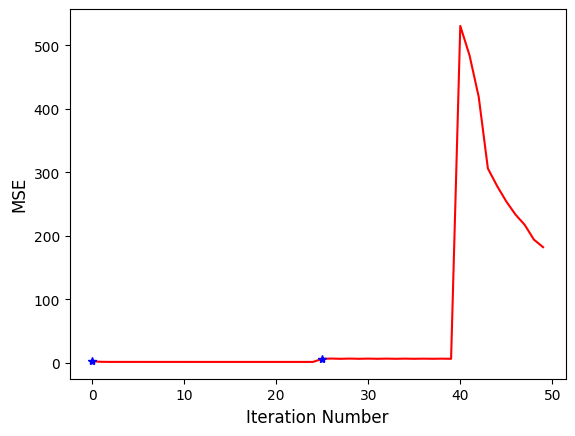

Stopping condition: RegularStepGradientDescentOptimizerv4: Maximum number of iterations (250) exceeded.
Metric value: 6.5420
avg_angle=-0.0193 avg_tx=0.0741 avg_ty=0.0255 avg_cx=127.5000 avg_cy=127.5000


In [22]:
slice = register_volume_inplane_weighted(v_unwindowed[1], v_unwindowed[0], verbose=True, n_samples=1, n_iters=250, lr=0.1, reg_window_min=-100, mask=True, multi_res=True)

Sadly, this volume has inter-volume movement (movement within each volume), so the weighted transformations method is not suitable here

In [13]:
def rigid_register_volume_sequence(volume_seq: np.ndarray, 
                                   reference_index: int = 4,
                                   n_iters: int = 100,
                                   n_samples: int = 3,
                                   lr: float = 0.1,
                                   mask = True,
                                   multi_res: bool = True,
                                   smoothing_sigma: float = 0.0,
                                   reg_clipping_vals = (0, 80),
                                   max_step = 0.0625,
                                   relaxation_factor = 0.5,
                                   shrink_factors = [2, 1],
                                   smoothing_sigmas = [2, 0],
                                   verbose: bool = True) -> np.ndarray:
    """
    Performs skull-based rigid registration on a sequence of volumes using the specified reference volume.

    Parameters:
    - volume_seq (np.ndarray): 4D array of shape (T, Y, Z, X) representing the volume sequence.
    - spacing (tuple): Physical spacing of the volume (Y, Z, X). Defaults to (5.0, 0.488281, 0.488281).
    - reference_index (int): Index of the reference volume in the sequence to which other volumes will be registered.
    - registering_structure (str): The structure used in registration. One of: 'all', 'skull', 'brain'. Defaults to 'all'.
    - window_center (int): The center of the window in HU. Defaults to 40.
    - window_width (int): The width of the window in HU. Defaults to 400.

    Returns:
    - np.ndarray: 4D array of registered volumes with the same shape as the input.
    """
    if not (0 <= reference_index < volume_seq.shape[0]):
        raise IndexError(f"Reference index {reference_index} is out of bounds for volume sequence with length {volume_seq.shape[0]}.")
    
    reference_volume = volume_seq[reference_index]

    print(f"Reference volume: {reference_volume.shape}")
    # Initialize the output array
    registered_seq = np.empty_like(volume_seq)
    registered_seq[reference_index] = volume_seq[reference_index]

    # Register each volume sequentially
    for i in range(volume_seq.shape[0]):
        if i == reference_index:
            continue
            
        print(f"Registering volume {i}")
        registered_seq[i] = register_volume_inplane_weighted(
            moving_volume=volume_seq[i],
            reference_volume=reference_volume,
            n_samples=n_samples,
            lr=lr,
            n_iters=n_iters,
            max_step=max_step,
            relaxation_factor=relaxation_factor,
            multi_res=multi_res,
            smoothing_sigma=smoothing_sigma,

            reg_window_max=reg_clipping_vals[1],
            reg_window_min=reg_clipping_vals[0],
            mask=mask,
            verbose=verbose,
        )

    print("All registrations completed.")
    return registered_seq

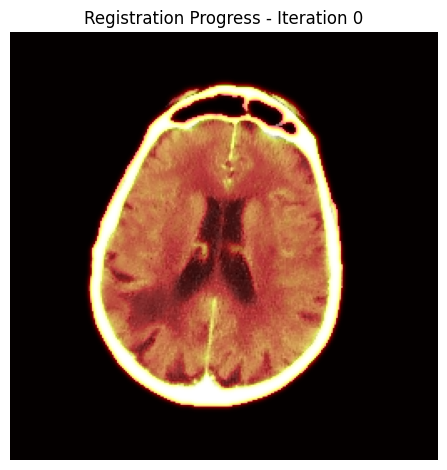

Iteration: 0
Metric value: 5.4643
Stopping condition: RegularStepGradientDescentOptimizerv4: Step too small after 3 iterations. Current step (0.0025) is less than minimum step (0.005).
Metric value: 5.4603
avg_angle=-0.0011 avg_tx=0.0010 avg_ty=-0.0000 avg_cx=127.5000 avg_cy=127.5000
All registrations completed.


In [14]:
v_reg = rigid_register_volume_sequence(v_unwindowed[::2], lr=0.01, reference_index=1, multi_res=False, mask=True,smoothing_sigma=2.0, n_iters=200, verbose=True)

In [15]:
multi_vol_seq_interactive([np.clip(v_unwindowed[::2], 0, 160), np.clip(v_reg, 0, 160)])

interactive(children=(IntSlider(value=0, description='Time:', max=8), IntSlider(value=0, description='Slice:',…

In [16]:
import pickle
scan_ids = ["/MOL-" + s for s in ['063', '092', '098', '104', '133']]
# exit()
paths = [dataset_path + sid for sid in scan_ids]
print("loading scans")
if os.path.exists("registration_scans.pkl"):
    with open("registration_scans.pkl", "rb") as f:
        scans = pickle.load(f)[:len(scan_ids)]
else:
    scans = [get_volume(path, 
                extract_brain=False, 
                filter=True, 
                window_params=None, 
                correct_motion=False, 
                standardize=False, 
                spatial_downsampling_factor=2, 
                temporal_downsampling_factor=2,
                verbose=False
                ) for path in paths]    

loading scans


## Case Study: MOL-092; intra-scan-volume movement

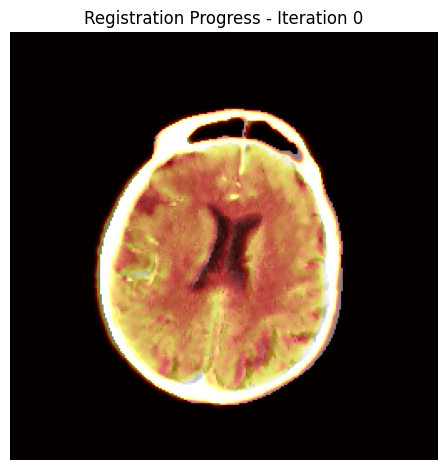

Iteration: 0
Metric value: 34.1914
Stopping condition: RegularStepGradientDescentOptimizerv4: Step too small after 13 iterations. Current step (0.003125) is less than minimum step (0.005).
Metric value: 31.0697
avg_angle=-0.0697 avg_tx=-0.9807 avg_ty=0.0379 avg_cx=127.5000 avg_cy=127.5000
All registrations completed.


In [17]:
_reg = rigid_register_volume_sequence(scans[1], reference_index=3, lr=0.1, multi_res=True, mask=True,smoothing_sigma=1.0, n_iters=200, verbose=True)

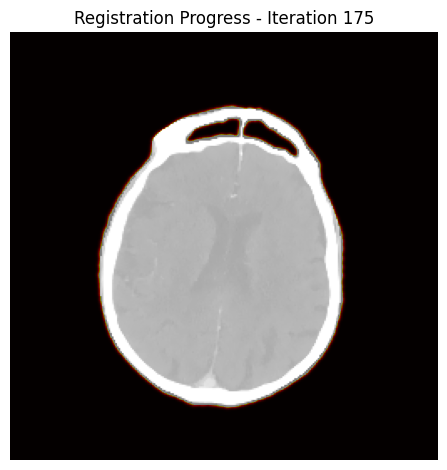

Iteration: 175
Metric value: 3488.3085
Stopping condition: RegularStepGradientDescentOptimizerv4: Maximum number of iterations (200) exceeded.
Metric value: 2980.8704
avg_angle=-0.0850 avg_tx=-1.9407 avg_ty=-0.8475 avg_cx=53.8424 avg_cy=53.8424


array([[[-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        [-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        [-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        ...,
        [-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        [-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        [-3024., -3024., -3024., ..., -3024., -3024., -3024.]],

       [[-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        [-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        [-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        ...,
        [-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        [-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        [-3024., -3024., -3024., ..., -3024., -3024., -3024.]],

       [[-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        [-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        [-3024., -3024., -3024., ..., -3024., -3024., -3024.],
        ...,
        [-30

In [18]:
register_volume_inplane_weighted(scans[1][0], scans[1][2], multi_res=False, n_samples=3, n_iters=200, lr=1.0, mask=True, verbose=True, wait=True)

In [126]:
multi_vol_seq_interactive(np.clip(np.array([scans[1][::2], _reg]), 0, 160))

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

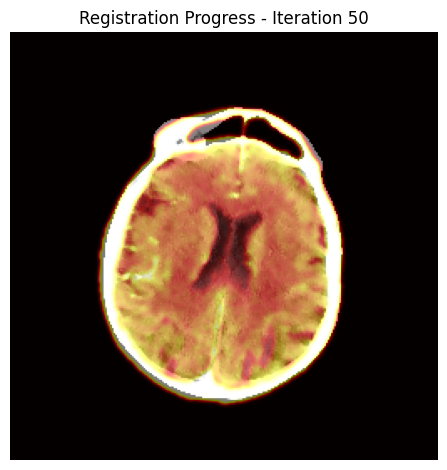

Iteration: 50
Metric value: 77.2578
Stopping condition: RegularStepGradientDescentOptimizerv4: Step too small after 61 iterations. Current step (0.003125) is less than minimum step (0.005).
Metric value: 76.2896
avg_angle=-0.0794 avg_tx=-1.8113 avg_ty=0.6119 avg_cx=127.5000 avg_cy=127.5000
All registrations completed.


In [129]:
__reg = rigid_register_volume_sequence(scans[1], reference_index=1, lr=0.1, multi_res=True, mask=True,smoothing_sigma=1.0, n_iters=200, verbose=True)

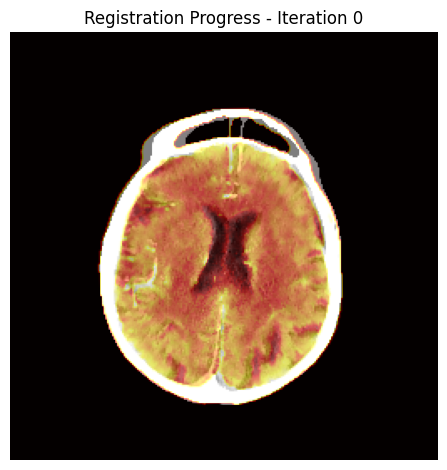

Iteration: 0
Metric value: 77.4612
Stopping condition: RegularStepGradientDescentOptimizerv4: Step too small after 23 iterations. Current step (0.003125) is less than minimum step (0.005).
Metric value: 68.8102
avg_angle=-0.0686 avg_tx=-0.6075 avg_ty=0.0269 avg_cx=127.5000 avg_cy=127.5000
All registrations completed.


In [136]:
___reg = rigid_register_volume_sequence(scans[1], reference_index=2, lr=0.1, multi_res=True, mask=True,smoothing_sigma=0.0, n_iters=200, verbose=True)

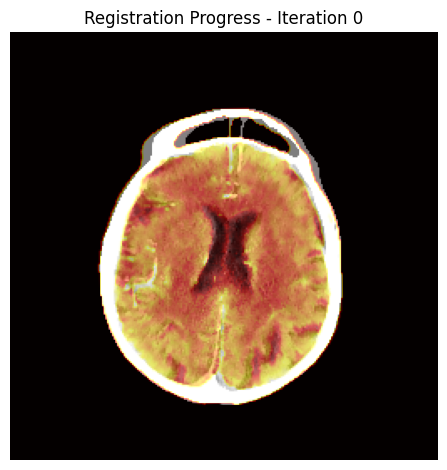

Iteration: 0
Metric value: 77.4612
Stopping condition: RegularStepGradientDescentOptimizerv4: Step too small after 23 iterations. Current step (0.003125) is less than minimum step (0.005).
Metric value: 68.8102
avg_angle=-0.0686 avg_tx=-0.6075 avg_ty=0.0269 avg_cx=127.5000 avg_cy=127.5000
All registrations completed.


In [138]:
___reg = rigid_register_volume_sequence(scans[1], reference_index=2, max_step=0.0625, lr=0.1, multi_res=True, mask=True,smoothing_sigma=0.0, n_iters=200, verbose=True)

In [134]:
multi_vol_seq_interactive(np.clip(np.array([scans[1], _reg, __reg]), 0, 160))

interactive(children=(IntSlider(value=0, description='Time:', max=8), IntSlider(value=0, description='Slice:',…

## Case Study

In [31]:
reg_scans = [rigid_register_volume_sequence(seq, reference_index=2, n_iters=150, verbose=False) for seq in scans]

Reference volume: (16, 256, 256)
Registering volume 0
Registering volume 1
Registering volume 3
Info: Large transformation detected for slice 10:
    Angle: -180.11°, Translation: (-3.56, 1.01)
Registering volume 4
Registering volume 5
Registering volume 6
Info: Large transformation detected for slice 10:
    Angle: -179.87°, Translation: (-3.17, 0.82)
Registering volume 7
Registering volume 8
All registrations completed.
Reference volume: (16, 256, 256)
Registering volume 0
Registering volume 1
Registering volume 3
Registering volume 4
Registering volume 5
Registering volume 6
Registering volume 7
Registering volume 8
All registrations completed.
Reference volume: (16, 256, 256)
Registering volume 0
Registering volume 1
Registering volume 3
Registering volume 4
Registering volume 5
Registering volume 6
Registering volume 7
Registering volume 8
All registrations completed.
Reference volume: (16, 256, 256)
Registering volume 0
Registering volume 1
Registering volume 3
Registering volume

In [ ]:
v_106

In [20]:
multi_vol_seq_interactive(np.clip(np.array(reg_scans), 0, 80))

interactive(children=(IntSlider(value=0, description='Time:', max=8), IntSlider(value=0, description='Slice:',…

In [ ]:
s1_reg = rigid_register_volume_sequence(scans[1], reference_index=4, n_iters=150, verbose=False)

Reference volume: (16, 256, 256)
Registering volume 0
Registering volume 1
Registering volume 2
Registering volume 3
Registering volume 5
Registering volume 6
Registering volume 7
Registering volume 8
All registrations completed.


In [ ]:
multi_vol_seq_interactive(np.clip(np.array([scans[1], s1_reg]), 0, 80))

interactive(children=(IntSlider(value=0, description='Time:', max=8), IntSlider(value=0, description='Slice:',…

In [23]:
register_volume_inplane_weighted(scans[0][0], scans[0][4], verbose=False, n_samples=3, n_iters=100, lr=1.0, reg_window_min=0, reg_window_max=80, mask=True, verbose=True)

SyntaxError: keyword argument repeated: verbose (323912948.py, line 1)

In [ ]:
def rigid_register_volume_sequence(volume_seq: np.ndarray, 
                                   reference_index: int = 4,
                                   n_iters: int = 100,
                                   n_samples: int = 3,
                                   lr: float = 1.0,
                                   mask = True,
                                   reg_clipping_vals = (0, 80),
                                   max_step = 1.0,
                                   relaxation_factor = 0.95,
                                   verbose: bool = True) -> np.ndarray:
    """
    Performs skull-based rigid registration on a sequence of volumes using the specified reference volume.

    Parameters:
    - volume_seq (np.ndarray): 4D array of shape (T, Y, Z, X) representing the volume sequence.
    - spacing (tuple): Physical spacing of the volume (Y, Z, X). Defaults to (5.0, 0.488281, 0.488281).
    - reference_index (int): Index of the reference volume in the sequence to which other volumes will be registered.
    - registering_structure (str): The structure used in registration. One of: 'all', 'skull', 'brain'. Defaults to 'all'.
    - window_center (int): The center of the window in HU. Defaults to 40.
    - window_width (int): The width of the window in HU. Defaults to 400.

    Returns:
    - np.ndarray: 4D array of registered volumes with the same shape as the input.
    """
    if not (0 <= reference_index < volume_seq.shape[0]):
        raise IndexError(f"Reference index {reference_index} is out of bounds for volume sequence with length {volume_seq.shape[0]}.")
    
    reference_volume = volume_seq[reference_index]

    print(f"Reference volume: {reference_volume.shape}")
    # Initialize the output array
    registered_seq = np.empty_like(volume_seq)
    registered_seq[reference_index] = volume_seq[reference_index]

    # Register each volume sequentially
    for i in range(volume_seq.shape[0]):
        if i == reference_index:
            continue
            
        print(f"Registering volume {i}")
        registered_seq[i] = register_volume_inplane_weighted(
            moving_volume=volume_seq[i],
            reference_volume=reference_volume,
            n_samples=n_samples,
            lr=lr,
            n_iters=n_iters,
            max_step=max_step,
            relaxation_factor=relaxation_factor,
            multi_res=True,
            smoothing_sigma=0,
            reg_window_max=reg_clipping_vals[1],
            reg_window_min=reg_clipping_vals[0],
            mask=mask,
            verbose=verbose,
        )

    print("All registrations completed.")
    return registered_seq

In [16]:
def experiment_reg(moving_volume: np.ndarray, reference_volume: np.ndarray, n_samples: int = 5, 
               lr: float = 1.0, n_iters: int = 200, relaxation_factor: float = 0.99, multi_res: bool = False,
               gradient_magnitude_tolerance: float = 1e-5, max_step: float = 4.0, min_step: float = 5e-4, 
               spacing: tuple = (1, 1), smoothing_sigma: float = 2.0, interpolator=sitk.sitkLinear,
               mask=True, reg_window_min=-100, reg_window_max=300, threshold_min=0, threshold_max=500,
               verbose: bool = False):
    
    Y, Z, X = moving_volume.shape
    
    if n_samples > Y: n_samples = Y
    elif n_samples < 1: n_samples = 1
    middle = Y // 2
    half_range = n_samples // 2
    slice_indices = np.linspace(middle - half_range, middle + half_range, n_samples, dtype=int)
    
    mean_metric_value = 0
    transforms = []
    weights = np.zeros(n_samples)
    
    # Register each sampled slice
    for pos, slice_idx in enumerate(slice_indices):
        
        # Standard preprocessing for registration
        if mask:
            moving_slice = preprocess_slice_for_registration(moving_volume[slice_idx], reg_window_min=reg_window_min, reg_window_max=reg_window_max, threshold_min=threshold_min, threshold_max=threshold_max)
            fixed_slice = preprocess_slice_for_registration(reference_volume[slice_idx], reg_window_min=reg_window_min, reg_window_max=reg_window_max, threshold_min=threshold_min, threshold_max=threshold_max)
        else:
            moving_slice = np.clip(moving_volume[slice_idx], 0, 160)
            fixed_slice = np.clip(reference_volume[slice_idx], 0, 160)
            

        # Set min pixel value to 0 so that background aligns with pixels moved in by transformation during registration
        min_pixel_value = np.min(moving_slice)
        moving_slice, fixed_slice = moving_slice - min_pixel_value, fixed_slice - min_pixel_value

        # Convert to SimpleITK images
        moving_image = sitk.GetImageFromArray(moving_slice)
        fixed_image = sitk.GetImageFromArray(fixed_slice)
        
        if smoothing_sigma:
            moving_image = sitk.DiscreteGaussian(moving_image, smoothing_sigma)
            fixed_image = sitk.DiscreteGaussian(fixed_image, smoothing_sigma)
        
        # Set 2D spacing
        moving_image.SetSpacing(spacing)
        fixed_image.SetSpacing(spacing)
        
        # Initialize 2D transform
        initial_transform = sitk.CenteredTransformInitializer(
            fixed_image,
            moving_image,
            sitk.Euler2DTransform(),
            sitk.CenteredTransformInitializerFilter.GEOMETRY
        )
        
        # Setup registration method
        registration_method = sitk.ImageRegistrationMethod()
        registration_method.SetMetricAsMeanSquares()
        
        # Optimizer settings
        registration_method.SetOptimizerAsRegularStepGradientDescent(
            learningRate=lr,
            maximumStepSizeInPhysicalUnits=max_step,
            minStep=min_step,
            numberOfIterations=n_iters,
            gradientMagnitudeTolerance=gradient_magnitude_tolerance,
            relaxationFactor=relaxation_factor,
            
        )
        if multi_res:
            registration_method.SetShrinkFactorsPerLevel(shrinkFactors=[2, 4])
            registration_method.SetSmoothingSigmasPerLevel(smoothingSigmas=[1, 2])
            registration_method.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()
        registration_method.SetInitialTransform(initial_transform)
        registration_method.SetInterpolator(interpolator)
 
        try:
            final_transform = registration_method.Execute(fixed_image, moving_image)
            params = final_transform.GetParameters()
            transforms.append(params)

            metric_value = registration_method.GetMetricValue()
            mean_metric_value += metric_value / n_samples
            position_weight = 1 - ((slice_idx - middle) / (middle-1)) # The further away from the center, the lower the weight
            weight = 1 / ((metric_value) + 1e-10) * position_weight ** 1.5
            weights[pos] = weight

        except RuntimeError as e:
            print(f"Registration failed for slice {slice_idx}: {e}")
            continue
    
    # Normalize weights
    weights = weights / np.sum(weights)
    # print(weights)
    # Compute weighted average transformation
    avg_angle = 0
    avg_tx = 0
    avg_ty = 0

    for params, weight in zip(transforms, weights):
        angle, tx, ty = params[0], params[1], params[2]
        avg_angle += angle * weight
        avg_tx += tx * weight
        avg_ty += ty * weight


        # Create final average transform
    final_transform = sitk.Euler2DTransform()
    final_transform.SetAngle(avg_angle)
    final_transform.SetTranslation((avg_tx, avg_ty))
    final_transform.SetCenter((127, 127))
    
    # Apply transform to each slice of moving volume
    registered_volume = np.zeros_like(moving_volume)
    for i in range(moving_volume.shape[0]):
        moving_slice = moving_volume[i]
        min_value = np.min(moving_slice)
        moving_slice = sitk.GetImageFromArray(moving_slice - min_value)
        registered_slice = sitk.Resample(
            moving_slice,
            final_transform,
            interpolator,
            0.0, # Min pixel value
            moving_slice.GetPixelID()
        )
        # Bring the slice back to its original value range by adding min_pixel_value
        registered_volume[i] = sitk.GetArrayFromImage(registered_slice) + min_value
    return registered_volume